<a href="https://colab.research.google.com/github/deoreshree/task16/blob/main/task16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
uploaded = files.upload()

Saving insurance.csv to insurance.csv


In [3]:
import pandas as pd

insurance = pd.read_csv("insurance.csv")
insurance.head(10)


,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86
5,31,female,25.7,0,no,southeast,3756.62
6,46,female,33.4,1,no,southeast,8240.59
7,37,female,27.7,3,no,northwest,7281.51
8,37,male,29.8,2,no,northeast,6406.41
9,60,female,25.8,0,no,northwest,28923.14


In [4]:
import pandas as pd

# Load the dataset
insurance = pd.read_csv("insurance.csv")

# 1. Shape of the dataset
print("Shape of the dataset:")
print(insurance.shape)

# 2. Column names and data types
print("\nDataset Information:")
insurance.info()

# 3. Statistical summary of numerical columns
print("\nStatistical Summary:")
print(insurance.describe())

Shape of the dataset:
(1338, 7)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   expenses  1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB

Statistical Summary:
               age          bmi     children      expenses
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.665471     1.094918  13270.422414
std      14.049960     6.098382     1.205493  12110.011240
min      18.000000    16.000000     0.000000   1121.870000
25%      27.000000    26.300000     0.000000   4740.287500
50%      39.000000    30.400000     1.000000   938

In [5]:
# Check missing values
print("Missing values in each column:")
print(insurance.isnull().sum())



Missing values in each column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
expenses    0
dtype: int64


In [6]:
# Numerical columns
numerical_cols = insurance.select_dtypes(include=['int64', 'float64']).columns
print("Numerical Columns:")
print(numerical_cols)

# Categorical columns
categorical_cols = insurance.select_dtypes(include=['object']).columns
print("\nCategorical Columns:")
print(categorical_cols)

Numerical Columns:
Index(['age', 'bmi', 'children', 'expenses'], dtype='object')

Categorical Columns:
Index(['sex', 'smoker', 'region'], dtype='object')


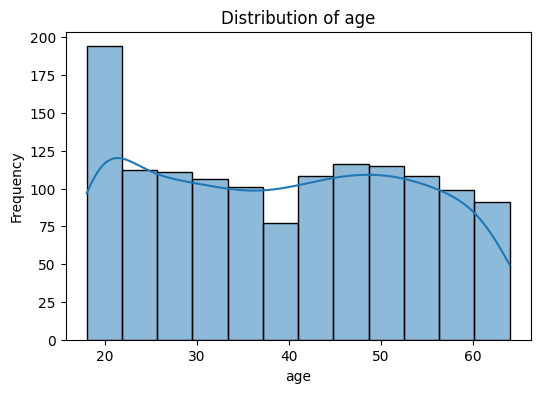

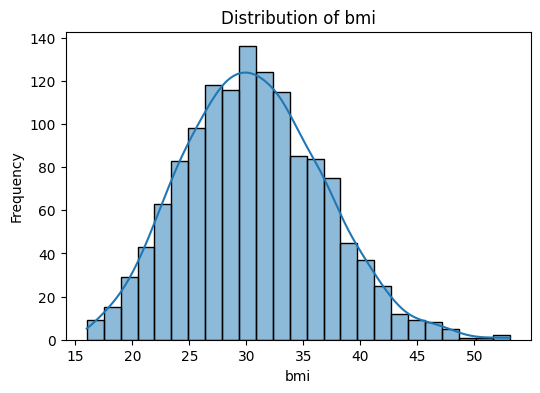

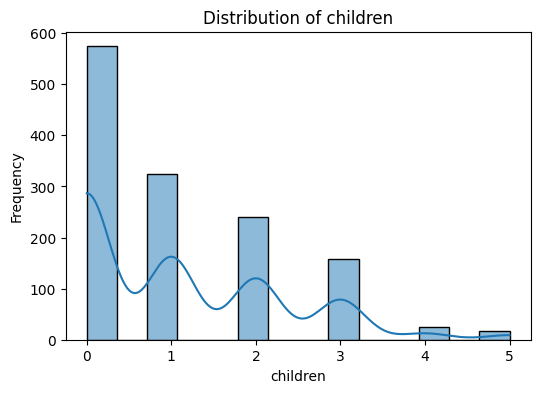

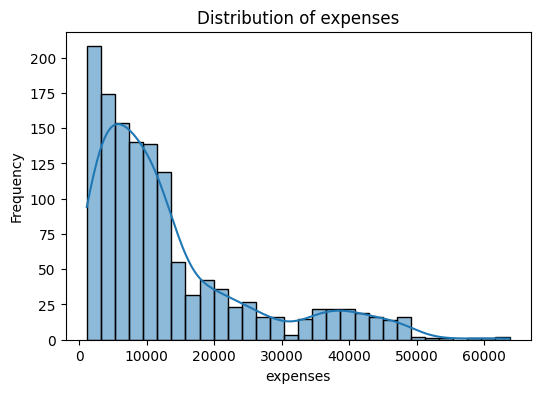

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = insurance.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(data=insurance, x=col, kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

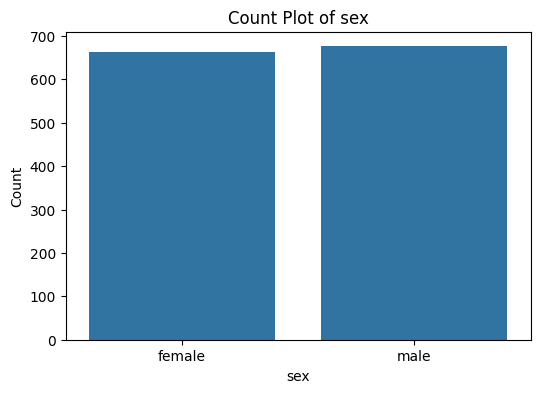

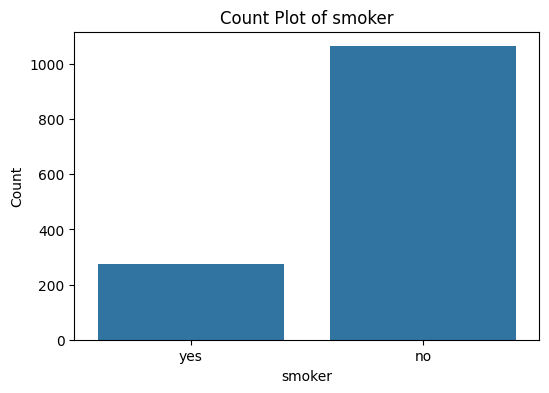

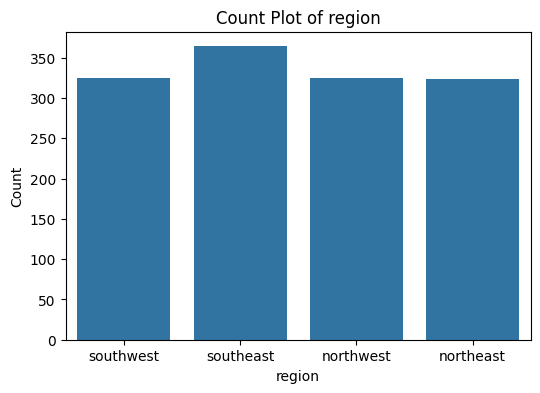

In [10]:
# List of categorical columns
cat_cols = ['sex', 'smoker', 'region']

for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=insurance[col])
    plt.title(f"Count Plot of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

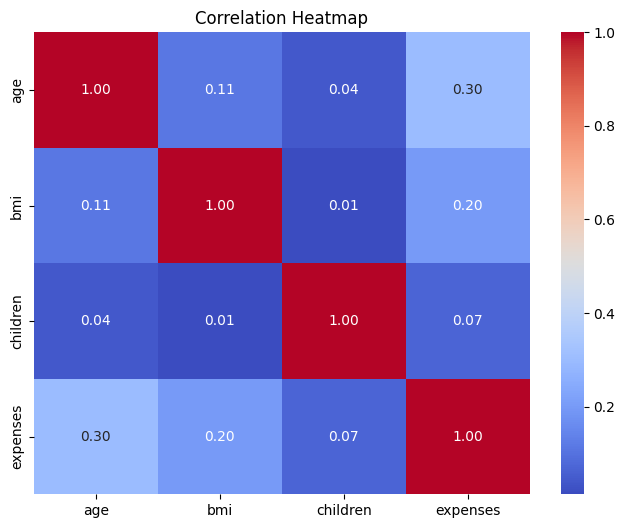

In [11]:
plt.figure(figsize=(8,6))

corr = insurance.select_dtypes(include=['int64', 'float64']).corr()

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title("Correlation Heatmap")
plt.show()

In [13]:
# Find the target column (charges/expenses/etc.)
target = None

if 'charges' in insurance.columns:
    target = 'charges'
elif 'expenses' in insurance.columns:
    target = 'expenses'
else:
    # Last numerical column
    target = numerical_cols[-1]

print("\nTarget Column:", target)

print("\nAverage:")
print(insurance[target].mean())

print("\nMaximum:")
print(insurance[target].max())

print("\nMinimum:")
print(insurance[target].min())

if 'smoker' in insurance.columns:
    print("\nAverage by Smoker:")
    print(insurance.groupby('smoker')[target].mean())



Target Column: expenses

Average:
13270.422414050823

Maximum:
63770.43

Minimum:
1121.87

Average by Smoker:
smoker
no      8434.268449
yes    32050.231971
Name: expenses, dtype: float64


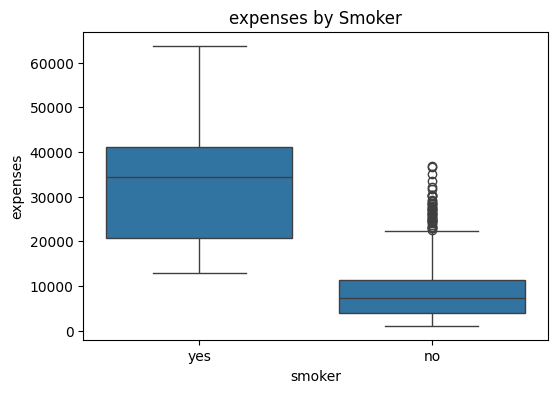

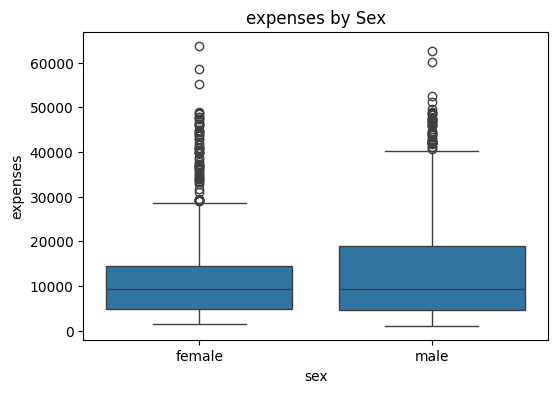

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

target = insurance.select_dtypes(include=['int64', 'float64']).columns[-1]

plt.figure(figsize=(6,4))
sns.boxplot(x='smoker', y=target, data=insurance)
plt.title(f"{target} by Smoker")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x='sex', y=target, data=insurance)
plt.title(f"{target} by Sex")
plt.show()

In [16]:
# Mini Project - Analysis Summary

# 1. Average age and BMI are calculated using:
#    insurance['age'].mean()
#    insurance['bmi'].mean()

# 2. Smokers have significantly higher insurance charges
#    compared to non-smokers.

# 3. The region with the highest number of customers is obtained using:
#    insurance['region'].value_counts().idxmax()

# 4. Observations:
#    - Charges are right-skewed.
#    - Most BMI values are between 25 and 35.
#    - Male and female customers are nearly equal in number.
#    - Smokers pay much higher insurance charges.
#    - Customer distribution across regions is fairly balanced.